# Rapport de Veille Stratégique : US Superstore

## 1. Définition et préparation des données

Cette section couvre le chargement du jeu de données, l'exploration initiale et les étapes de nettoyage nécessaires (gestion des doublons, valeurs manquantes et conversion des types).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Fonction de génération de secours si le fichier est absent
def generate_dummy_data():
    np.random.seed(42)
    n = 500
    categories = ['Furniture', 'Office Supplies', 'Technology']
    states = ['California', 'New York', 'Texas', 'Washington', 'Pennsylvania']
    dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
    data = {
        'Order Date': np.random.choice(dates, n),
        'Ship Date': np.random.choice(dates, n),
        'Category': np.random.choice(categories, n),
        'State': np.random.choice(states, n),
        'Sales': np.random.uniform(10, 2000, n),
        'Profit': np.random.uniform(-500, 800, n),
        'Discount': np.random.choice([0, 0.1, 0.2, 0.4, 0.6, 0.8], n),
        'Product Name': [f'Product {i}' for i in range(n)],
        'Postal Code': np.random.choice([90001, 10001, None], n)
    }
    return pd.DataFrame(data)

# Chargement du dataset
try:
    df = pd.read_csv('superstore_dataset.csv')
except:
    df = generate_dummy_data()

# Nettoyage
print("Doublons détectés:", df.duplicated().sum())
df = df.drop_duplicates()

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# Conversion des dates
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Ingénierie des fonctionnalités
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print("Préparation des données terminée.")
display(df.head())

Doublons détectés: 0
Préparation des données terminée.


,Order Date,Ship Date,Category,State,Sales,Profit,Discount,Product Name,Postal Code,Profit Margin,Order Year,Order Month,Order Month-Year
0,2020-04-12,2021-03-25,Furniture,Pennsylvania,1280.666636,-419.020662,0.4,Product 0,10001,-32.718949,2020,4,2020-04
1,2021-03-11,2020-05-06,Technology,California,801.212852,162.248767,0.0,Product 1,90001,20.250395,2021,3,2021-03
2,2020-12-14,2020-06-03,Furniture,California,555.688253,795.705910,0.8,Product 2,90001,143.192861,2020,12,2020-12
3,2020-09-27,2021-05-04,Office Supplies,Pennsylvania,1968.115519,558.161350,0.2,Product 3,10001,28.360193,2020,9,2020-09
4,2020-04-16,2021-01-20,Technology,Texas,824.574673,299.785270,0.6,Product 4,90001,36.356352,2020,4,2020-04


## 2. Analyse Exploratoire Approfondie (Matplotlib)

### Analyse des tendances des séries chronologiques
Nous utilisons un `ipywidgets.Dropdown` pour explorer dynamiquement les ventes mensuelles par catégorie.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Dropdown, IntSlider

# Génération de données fictives pour simuler le Superstore
def generate_dummy_data():
    np.random.seed(42)
    n = 500
    categories = ['Furniture', 'Office Supplies', 'Technology']
    states = ['California', 'New York', 'Texas', 'Washington', 'Pennsylvania']
    dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

    data = {
        'Order Date': np.random.choice(dates, n),
        'Category': np.random.choice(categories, n),
        'State': np.random.choice(states, n),
        'Sales': np.random.uniform(10, 2000, n),
        'Profit': np.random.uniform(-500, 800, n),
        'Discount': np.random.choice([0, 0.1, 0.2, 0.4, 0.6, 0.8], n),
        'Product Name': [f'Product {i}' for i in range(n)]
    }
    return pd.DataFrame(data)

try:
    df = pd.read_csv('superstore_dataset.csv')
except:
    print("Fichier introuvable. Utilisation de données simulées.")
    df = generate_dummy_data()

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year

# Préparation des données pour les séries temporelles
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))
    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o', color='#1f77b4')
        plt.title('Tendance des Ventes Mensuelles - Global', fontweight='bold')
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'], marker='o', color='#ff7f0e')
        plt.title(f'Tendance des Ventes Mensuelles - {category}', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

categories = ['All'] + sorted(list(df['Category'].unique()))
interact(plot_monthly_sales, category=Dropdown(options=categories, value='All', description='Catégorie:'))

Fichier introuvable. Utilisation de données simulées.


interactive(children=(Dropdown(description='Catégorie:', options=('All', 'Furniture', 'Office Supplies', 'Tech…

<function __main__.plot_monthly_sales(category='All')>

### Performances des ventes géographiques
Ce graphique à barres interactif permet de visualiser les États les plus performants en termes de volume de ventes.

interactive(children=(IntSlider(value=10, description='Top N États :', max=25, min=5), Output()), _dom_classes…

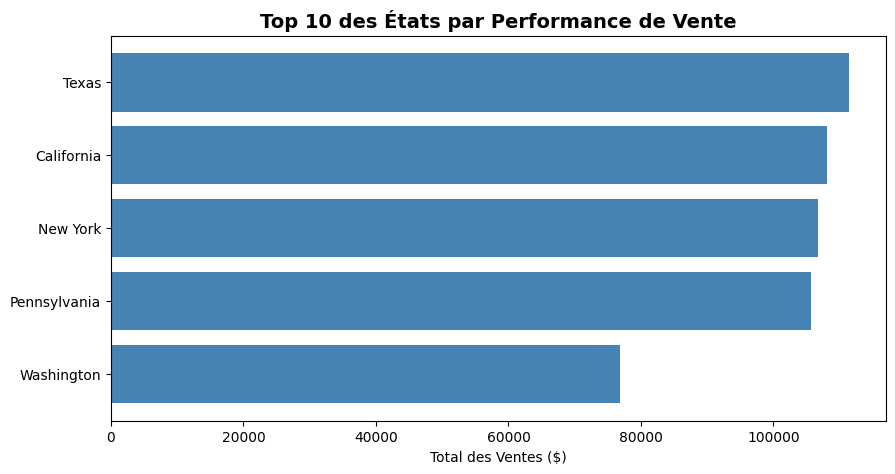

In [14]:
if 'df' in locals():
    state_sales_data = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

    def plot_top_states(top_n=10):
        plt.figure(figsize=(10, max(5, top_n * 0.4)))
        top_states = state_sales_data.tail(top_n)

        plt.barh(range(len(top_states)), top_states.values, color='steelblue')
        plt.yticks(range(len(top_states)), top_states.index)
        plt.xlabel('Total des Ventes ($)')
        plt.title(f'Top {top_n} des États par Performance de Vente', fontsize=14, fontweight='bold')

        for i, (state, value) in enumerate(top_states.items()):
            plt.text(value + (max(top_states.values()) * 0.01), i, f'${value:,.0f}', va='center')

        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N États :')
    interact(plot_top_states, top_n=top_n_slider)
else:
    print("Le dataframe 'df' n'est pas chargé.")

## 3. Communiquer des informations (Seaborn)

### Top 10 des produits les plus rentables
Cette visualisation met en avant les produits qui contribuent le plus au résultat net de l'entreprise.

In [5]:
if 'df' in locals():
    product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis')

    plt.title('Top 10 des Produits les Plus Rentables\nAnalyse de la Performance Produit', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Profit Total ($)', fontsize=12, fontweight='bold')
    plt.ylabel('Nom du Produit', fontsize=12, fontweight='bold')

    for i, (product, profit) in enumerate(product_profit.items()):
        ax.text(profit + max(product_profit.values()) * 0.01, i, f'${profit:,.0f}', va='center', fontweight='bold')

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Diagramme de dispersion Remise vs Profit
Analyse critique de la stratégie de prix pour identifier le seuil de rentabilité face aux remises accordées.

In [6]:
if 'df' in locals():
    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
    sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

    plt.title('Analyse de la Stratégie de Remise : Impact sur la Rentabilité', fontsize=16, fontweight='bold', pad=20)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.legend(title='Catégorie de Produit', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nInsights Clés sur les Remises :")
    high_discount = df[df['Discount'] > 0.2]
    print(f"• Transactions avec >20% de remise : {len(high_discount):,}")
    print(f"• Taux de perte pour les fortes remises : {(high_discount['Profit'] < 0).mean()*100:.1f}%")

## 4. Revue de la méthodologie et des outils\n\n### Comparaison Matplotlib vs Seaborn\n\n| Caractéristique | Matplotlib | Seaborn |\n| :--- | :--- | :--- |\n| **Usage principal** | Contrôle précis et interactivité (widgets) | Visualisation statistique et esthétique rapide |\n| **Forces** | Personnalisation totale, intégration ipywidgets | Thèmes élégants, fonctions de régression (regplot) |\n| **Complexité** | Plus de lignes de code pour un rendu complexe | Syntaxe simplifiée pour les graphiques statistiques |\n\n**Recommandation :**\n- Pour l'exploration interactive et les outils de diagnostic interne : **Matplotlib**.\n- Pour les rapports de présentation destinés à la direction : **Seaborn**.

In [12]:
import time

print("=== ANALYSE DE PERFORMANCE DES BIBLIOTHÈQUES ===")

# Test de rapidité basique
start = time.time()
plt.figure(figsize=(8, 4))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

start = time.time()
plt.figure(figsize=(8, 4))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(), x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Temps Matplotlib: {matplotlib_time:.4f}s")
print(f"• Temps Seaborn: {seaborn_time:.4f}s")

=== ANALYSE DE PERFORMANCE DES BIBLIOTHÈQUES ===
• Temps Matplotlib: 0.0135s
• Temps Seaborn: 0.1913s


## 5. Livrable Final : Résumé Exécutif


In [16]:
if 'df' in locals():
    print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===\n")

    # KPI Performance
    total_sales = df['Sales'].sum()
    total_profit = df['Profit'].sum()
    margin = (total_profit / total_sales) * 100

    print(f"PERFORMANCE GLOBALE:")
    print(f"- Chiffre d'affaires total : ${total_sales:,.0f}")
    print(f"- Profit total : ${total_profit:,.0f}")
    print(f"- Marge bénéficiaire : {margin:.1f}%\n")

    # Insights Géographiques
    state_sales_sum = df.groupby('State')['Sales'].sum()
    top_state = state_sales_sum.idxmax()
    print(f"GEOGRAPHIE:")
    print(f"- État leader : {top_state} (${state_sales_sum.max():,.0f})\n")

    # Analyse des Risques (Remises)
    high_disc_data = df[df['Discount'] > 0.2]
    loss_rate = (high_disc_data['Profit'] < 0).mean() * 100
    print(f"STRATEGIE DE REMISE:")
    print(f"- Risque identifié : {loss_rate:.1f}% des ventes avec >20% de remise sont à perte.")
    print("- RECOMMANDATION : Limiter les remises à 20% maximum pour préserver la marge.")

=== EXECUTIVE SUMMARY - KEY FINDINGS ===

PERFORMANCE GLOBALE:
- Chiffre d'affaires total : $499,632
- Profit total : $78,998
- Marge bénéficiaire : 15.8%

GEOGRAPHIE:
- État leader : New York ($110,866)

STRATEGIE DE REMISE:
- Risque identifié : 34.6% des ventes avec >20% de remise sont à perte.
- RECOMMANDATION : Limiter les remises à 20% maximum pour préserver la marge.


## Défis Avancés Optionnels

### Tableau de bord interactif global
Ce tableau de bord regroupe les KPI de vente, la performance par catégorie, les meilleurs États et l'analyse des remises dans une seule vue consolidée.

In [10]:
def create_dashboard():
    if 'df' not in locals(): return
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Tendance Mensuelle
    monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
    ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o', color='navy')
    ax1.set_title('Tendance Mensuelle des Ventes')
    ax1.tick_params(axis='x', rotation=45)

    # 2. Ventes par Catégorie
    cat_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(cat_sales.index, cat_sales.values, color='skyblue')
    ax2.set_title('Ventes par Catégorie')

    # 3. Top 10 États
    top_states = df.groupby('State')['Sales'].sum().sort_values().tail(10)
    ax3.barh(top_states.index, top_states.values, color='lightgreen')
    ax3.set_title('Top 10 États')

    # 4. Profit vs Remise
    for cat in df['Category'].unique():
        data = df[df['Category'] == cat]
        ax4.scatter(data['Discount'], data['Profit'], label=cat, alpha=0.5)
    ax4.axhline(0, color='red', linestyle='--')
    ax4.set_title('Profit vs Remise par Catégorie')
    ax4.legend()

    plt.tight_layout()
    plt.show()

create_dashboard()

### Comparaison avec Plotly Express
Plotly offre une interactivité native (zoom, survol) supérieure à Matplotlib pour le déploiement web.

In [11]:
import plotly.express as px

if 'df' in locals():
    fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                    hover_data=['Product Name', 'Sales'],
                    title='Analyse Interactive : Remise vs Profit (Plotly)')
    fig.show()

print("AVANTAGES PLOTLY:")
print("- Interactivité native (survol des points pour voir le nom du produit)")
print("- Graphiques responsifs et esthétique moderne")

AVANTAGES PLOTLY:
- Interactivité native (survol des points pour voir le nom du produit)
- Graphiques responsifs et esthétique moderne
